Dataset shape: (17597, 6)

Model Performance
------------------
R2 Score: 0.9454545211946135
MAE: 0.5928320644199521
RMSE: 1.040845962547464

Feature Importance
              Feature  Importance
2          Course_deg    0.290046
1          Altitude_m    0.277126
5           speed_sat    0.190256
7      hdop_sat_ratio    0.128063
6  altitude_sat_ratio    0.060305
0          Speed_kmph    0.036013
3                Sats    0.013004
4               HDOPs    0.005187


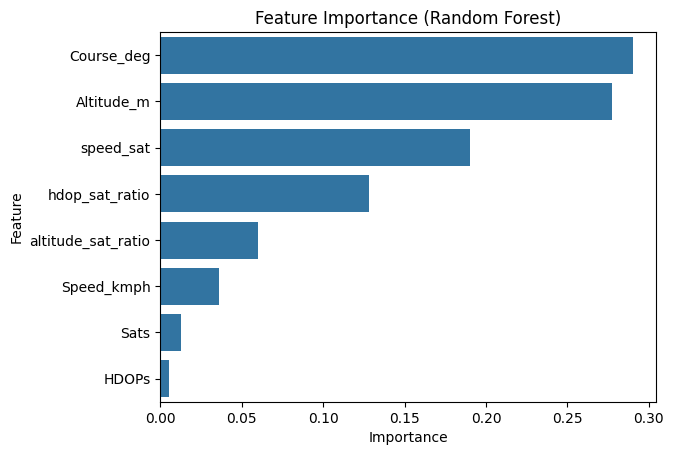

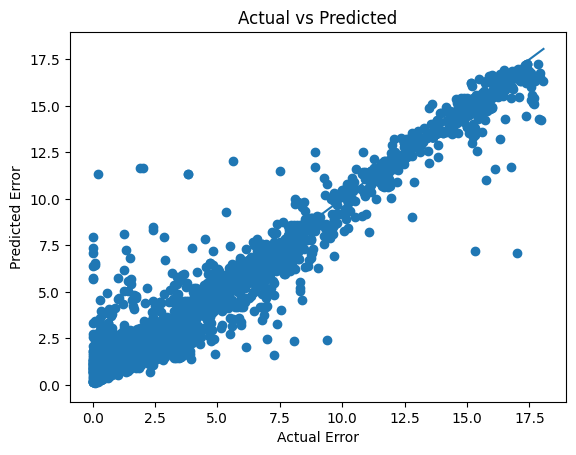

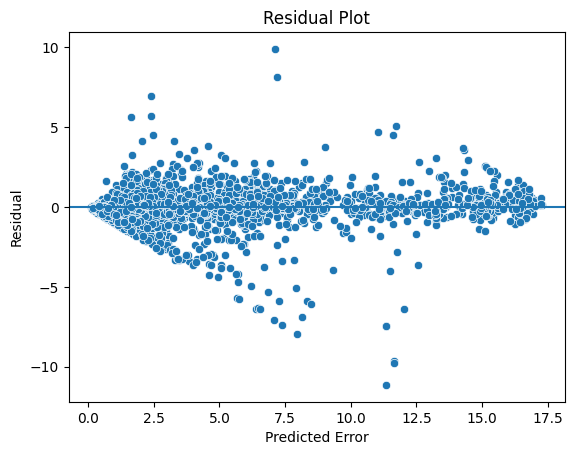

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# ------------------------------------------------
# 1 Feature Engineering Function (Reusable)
# ------------------------------------------------

def prepare_features(df):
    df["speed_sat"] = df["Speed_kmph"] * df["Sats"]
    df["altitude_sat_ratio"] = df["Altitude_m"] / (df["Sats"] + 1)
    df["hdop_sat_ratio"] = df["HDOPs"] / (df["Sats"] + 1)
    return df


# ------------------------------------------------
# 2 Load Dataset
# ------------------------------------------------

df = pd.read_csv("data.csv")

df = df[['Speed_kmph','Altitude_m','Course_deg','Sats','HDOPs','Error_meters']]

df = df.dropna()

print("Dataset shape:", df.shape)


# ------------------------------------------------
# 3 Remove extreme outliers
# ------------------------------------------------

upper = df["Error_meters"].quantile(0.99)
df = df[df["Error_meters"] < upper]


# ------------------------------------------------
# 4 Feature Engineering
# ------------------------------------------------

df = prepare_features(df)


# ------------------------------------------------
# 5 Define Features / Target
# ------------------------------------------------

features = [
    'Speed_kmph',
    'Altitude_m',
    'Course_deg',
    'Sats',
    'HDOPs',
    'speed_sat',
    'altitude_sat_ratio',
    'hdop_sat_ratio'
]

X = df[features]
y = df["Error_meters"]


# ------------------------------------------------
# 6 Train Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ------------------------------------------------
# 7 Train Random Forest
# ------------------------------------------------

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# ------------------------------------------------
# 8 Predictions
# ------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------
# 9 Evaluation
# ------------------------------------------------

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance")
print("------------------")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


# ------------------------------------------------
# 10 Feature Importance
# ------------------------------------------------

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance_df)


plt.figure()
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()


# ------------------------------------------------
# 11 Actual vs Predicted Plot
# ------------------------------------------------

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Error")
plt.ylabel("Predicted Error")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()


# ------------------------------------------------
# 12 Residual Plot
# ------------------------------------------------

residuals = y_test - y_pred

plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)

plt.xlabel("Predicted Error")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()


# ------------------------------------------------
# 13 SAVE MODEL (JOBLIB)
# ------------------------------------------------



In [2]:
joblib.dump(model, "gps_error_model.joblib")
joblib.dump(features, "model_features.joblib")

print("\n✅ Model saved as gps_error_model.joblib")
print("✅ Features saved as model_features.joblib")


✅ Model saved as gps_error_model.joblib
✅ Features saved as model_features.joblib
